# Proyecto 04 · Notebook 03 — Solape y unicidad

Las etiquetas del notebook 02 no son observaciones independientes. La etiqueta del evento en `t0`
la decide lo que hace el precio en `(t0, t1]`; si muestreo un evento por barra y las apuestas duran
14 barras, dos filas consecutivas comparten **13 de sus 14 barras de retorno**. No son dos
observaciones: son una y pico.

AFML propone medir ese "y pico" (concurrencia, unicidad media) y corregirlo con pesos muestrales.
Este notebook implementa todo eso desde cero y luego hace la pregunta incómoda: **¿cuánta
información hay realmente en la muestra, y cambia si muestreo más denso?**

### Predicción registrada *antes* de ejecutar

> Unicidad media **~1/N ~ 0.05** con una observación por barra y `N=20`, subiendo hacia 1.0 con
> ventanas disjuntas. Y la predicción fuerte: **el tamaño muestral efectivo `n x ū` será
> aproximadamente constante ~ `T/N` ~ 75 en los tres esquemas** — muestrear más denso añade filas
> pero no información. Un shock único contaminará **~N/s observaciones** (creciente con la
> densidad) pero una **fracción constante** del total.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "04_labeling_pitfalls"
sys.path.insert(0, str(PROJ / "src"))

from synth import SimConfig, simulate
from labeling import ewma_vol, triple_barrier, cusum_events
from uniqueness import (indicator_matrix, num_concurrent_events, average_uniqueness,
                        return_attribution_weights, uniqueness_weights,
                        effective_sample_size, kish_ess)
from experiments import SEEDS, over_seeds, summarise, mean_ci, fmt_ci, paired_test

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "figure.dpi": 110, "font.size": 9})
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_HOLD = 20
BASE = SimConfig(signal_two_sided=True)

def build(seed):
    sd = simulate(BASE.with_(seed=seed))
    sd.sigma1 = ewma_vol(sd.bars.close)
    sd.sigma_h = sd.sigma1 * np.sqrt(N_HOLD)
    sd.all_events = sd.bars.index[60:-(N_HOLD + 1)]
    return sd

def label(sd, events):
    return triple_barrier(sd.bars, events, sd.sigma_h, (1.0, 1.0), N_HOLD,
                          mode="path", fine=sd.fine)

d = build(0)
L = label(d, d.all_events)
print(f"{len(L)} eventos, uno por barra; duración media de la apuesta "
      f"{(L.i1 - L.i0).mean():.1f} barras de un máximo de {N_HOLD}")

1419 eventos, uno por barra; duración media de la apuesta 14.2 barras de un máximo de 20


## 1. Concurrencia y unicidad

Dos definiciones (AFML 4.1-4.2), ambas triviales de escribir y sorprendentemente informativas:

* **concurrencia** `c_t` = cuántas ventanas de evento están vivas en la barra `t`.
* **unicidad media** de un evento = promedio de `1/c_t` sobre su propia ventana. Vale 1 si nadie
  comparte ni una barra con él, y tiende a 0 cuando todos se solapan con todos.

La matriz indicadora `(barras x eventos)` es la representación explícita del solape. La construyo
para verla, pero para calcular uso una suma acumulada: la matriz es `O(barras x eventos)` en
memoria y no hace falta.

matriz indicadora del tramo: 60 barras x 25 eventos  (eventos vivos por barra en el tramo: 8.8)


t0,2016-07-15,2016-07-18,2016-07-19,2016-07-20,2016-07-21,2016-07-22,2016-07-25,2016-07-26,2016-07-27,2016-07-28
date,,,,,,,,,,
2016-07-15,1,0,0,0,0,0,0,0,0,0
2016-07-18,1,1,0,0,0,0,0,0,0,0
2016-07-19,1,1,1,0,0,0,0,0,0,0
2016-07-20,1,1,1,1,0,0,0,0,0,0
2016-07-21,1,1,1,1,1,0,0,0,0,0
2016-07-22,1,1,1,1,1,1,0,0,0,0
2016-07-25,1,1,1,1,1,1,1,0,0,0
2016-07-26,1,1,1,1,1,1,1,1,0,0


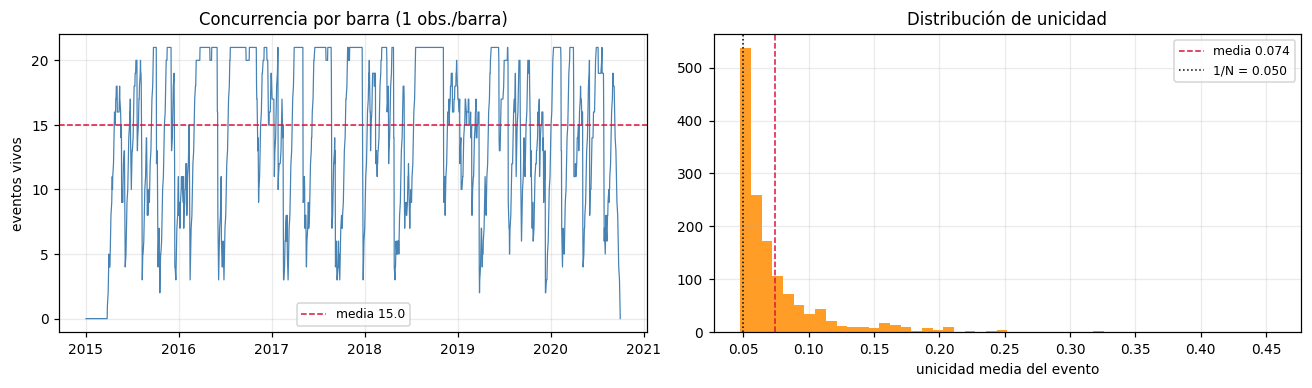

concurrencia media (barras activas): 14.99
unicidad media: 0.0739   (1/N = 0.0500, 1/duración media = 0.0704)


In [2]:
co = num_concurrent_events(d.bars.index, L)
u = average_uniqueness(d.bars.index, L, co)

sl = slice(400, 460)
L_sub = L[(L.i0 >= 400) & (L.i0 < 425)]
ind = indicator_matrix(d.bars.index, L_sub).iloc[sl]     # posiciones absolutas -> índice completo
print(f"matriz indicadora del tramo: {ind.shape[0]} barras x {ind.shape[1]} eventos  "
      f"(eventos vivos por barra en el tramo: {ind.sum(axis=1).mean():.1f})")
display(ind.iloc[:8, :10])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.plot(co.index, co.values, lw=0.8, color="steelblue")
a1.axhline(co[co > 0].mean(), color="crimson", ls="--", lw=1,
           label=f"media {co[co>0].mean():.1f}")
a1.set(ylabel="eventos vivos", title="Concurrencia por barra (1 obs./barra)"); a1.legend(fontsize=8)
a2.hist(u, bins=50, color="darkorange", alpha=0.85)
a2.axvline(u.mean(), color="crimson", ls="--", lw=1, label=f"media {u.mean():.3f}")
a2.axvline(1 / N_HOLD, color="k", ls=":", lw=1, label=f"1/N = {1/N_HOLD:.3f}")
a2.set(xlabel="unicidad media del evento", title="Distribución de unicidad"); a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "03_concurrency.png", bbox_inches="tight"); plt.show()

print(f"concurrencia media (barras activas): {co[co>0].mean():.2f}")
print(f"unicidad media: {u.mean():.4f}   (1/N = {1/N_HOLD:.4f}, "
      f"1/duración media = {1/(L.i1-L.i0).mean():.4f})")

## 2. El solape, dibujado

Un diagrama de Gantt de las ventanas `[t0, t1]`. Es la imagen que hace innecesario el resto del
argumento: con una observación por barra, cualquier corte vertical atraviesa ~15 ventanas
simultáneas. Un k-fold aleatorio pone unas a un lado del corte y otras al otro.

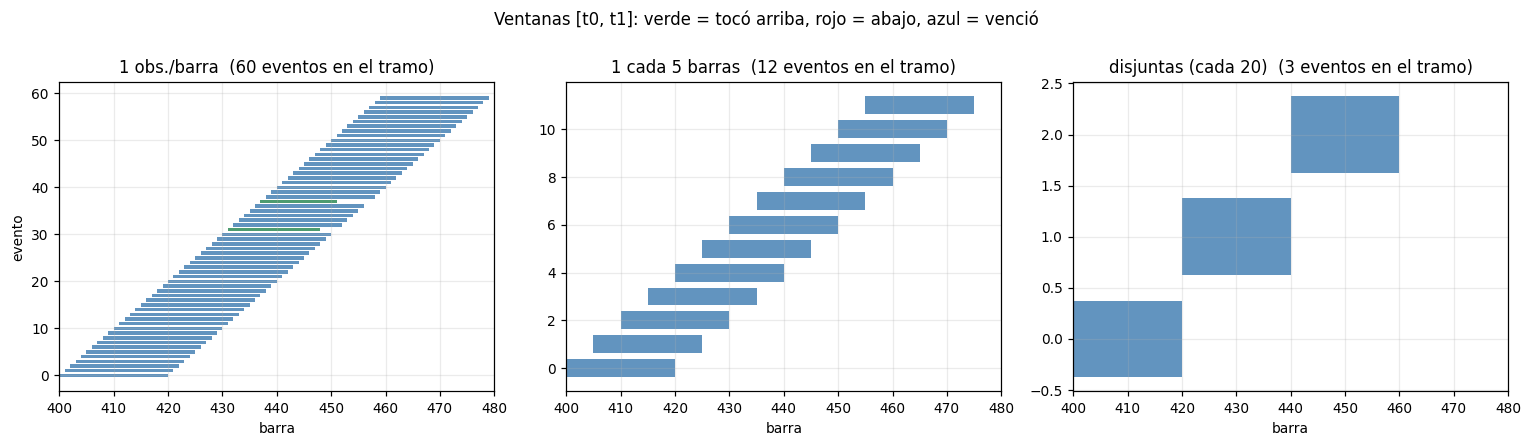

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
lo, hi = 400, 460
for ax, (every, name) in zip(axes, [(1, "1 obs./barra"), (5, "1 cada 5 barras"),
                                    (N_HOLD, f"disjuntas (cada {N_HOLD})")]):
    ev = d.all_events[::every]
    Le = label(d, ev)
    Le = Le[(Le.i0 >= lo) & (Le.i0 < hi)]
    for k, (t0, r) in enumerate(Le.iterrows()):
        ax.barh(k, r.i1 - r.i0, left=r.i0, height=0.75,
                color={"pt": "seagreen", "sl": "firebrick", "vert": "steelblue"}[r.barrier],
                alpha=0.85)
    ax.set(title=f"{name}  ({len(Le)} eventos en el tramo)", xlabel="barra",
           ylabel="evento" if every == 1 else "")
    ax.set_xlim(lo, hi + N_HOLD)
fig.suptitle("Ventanas [t0, t1]: verde = tocó arriba, rojo = abajo, azul = venció", y=1.0)
plt.tight_layout(); plt.savefig(PLOTS / "03_gantt.png", bbox_inches="tight"); plt.show()

## 3. Pesos: por unicidad y por atribución de retorno

Dos formas de decirle al estimador "esta fila vale menos que una fila entera":

* **por unicidad**: `w_i ∝ ū_i`. Cada observación pesa lo poco o mucho que le pertenece en
  exclusiva.
* **por atribución de retorno** (AFML 4.10): `w_i = |Σ_{t ∈ ventana_i} r_t / c_t|`. Reparte el
  retorno de cada barra entre los eventos vivos en ella y pesa por el retorno que le toca. Premia
  además a las observaciones que cubren movimientos grandes.

Y una comprobación que conviene hacer aunque nadie la pida: **¿cuánto vale realmente esta muestra?**
Uso dos estimadores del tamaño efectivo — `n·ū`, que mira el solape, y el de Kish
`(Σw)²/Σw²`, que solo mira la dispersión de los pesos.

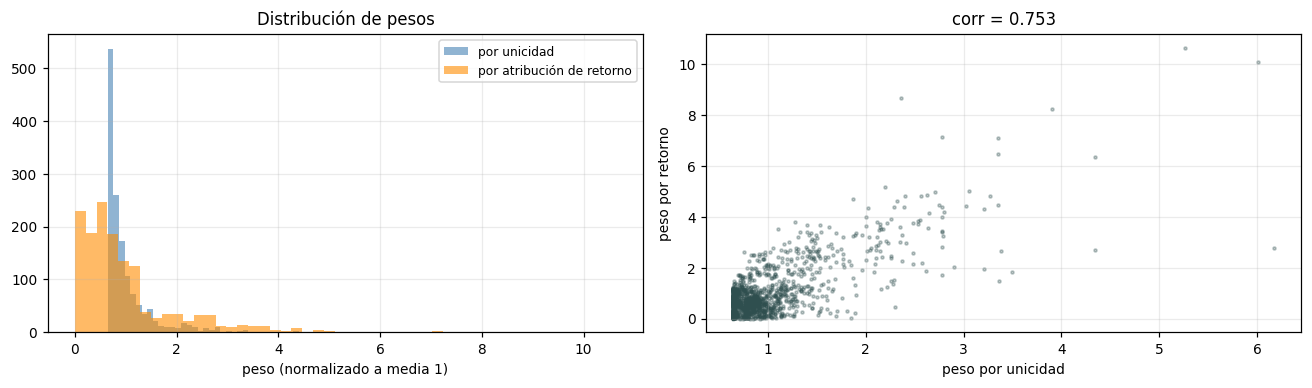

observaciones nominales           : 1419
tamaño efectivo  n * ū            : 104.9
tamaño efectivo de Kish, pesos ū  : 1101.1
tamaño efectivo de Kish, pesos ret: 663.4
T / duración media                : 99.9


In [4]:
w_u = uniqueness_weights(u)
w_r = return_attribution_weights(d.bars.index, L, d.bars.close, co)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.hist(w_u, bins=50, alpha=0.6, color="steelblue", label="por unicidad")
a1.hist(w_r, bins=50, alpha=0.6, color="darkorange", label="por atribución de retorno")
a1.set(xlabel="peso (normalizado a media 1)", title="Distribución de pesos"); a1.legend(fontsize=8)
a2.scatter(w_u, w_r, s=4, alpha=0.3, color="darkslategray")
a2.set(xlabel="peso por unicidad", ylabel="peso por retorno",
       title=f"corr = {np.corrcoef(w_u, w_r)[0,1]:.3f}")
plt.tight_layout(); plt.savefig(PLOTS / "03_weights.png", bbox_inches="tight"); plt.show()

print(f"observaciones nominales           : {len(L)}")
print(f"tamaño efectivo  n * ū            : {effective_sample_size(u):.1f}")
print(f"tamaño efectivo de Kish, pesos ū  : {kish_ess(w_u):.1f}")
print(f"tamaño efectivo de Kish, pesos ret: {kish_ess(w_r):.1f}")
print(f"T / duración media                : {len(L)/(L.i1-L.i0).mean():.1f}")

### Los dos estimadores no coinciden, y uno de ellos está midiendo otra cosa

Kish dice que la muestra vale ~1100 observaciones; `n·ū` dice ~105. La discrepancia no es un
error de cálculo: **el estimador de Kish supone independencia** y solo penaliza que unos pesos
sean mayores que otros. Aquí el problema no es la dispersión de los pesos, es que las filas
comparten retornos. Kish es ciego a eso por construcción.

Merece decirse claramente porque es una trampa fácil: **ponderar por unicidad no convierte la
muestra en 1100 puntos independientes**. Reduce el sesgo con el que el estimador cuenta las
observaciones redundantes, pero la información sigue siendo la que es. Si alguien reporta un
intervalo de confianza calculado con `n=1419` sobre estas etiquetas, está mintiendo por un factor
de raíz de 13.

## 4. Propagación: un solo evento, ¿en cuántas etiquetas aparece?

El experimento más directo posible. Inyecto **un único shock** en la barra `t*` — un salto
multiplicativo permanente de `1.5 x sigma_h`, o sea vez y media la anchura de barrera local — y
cuento en cuántas etiquetas se nota, para varias densidades de muestreo.

Dos medidas distintas, y la diferencia entre ellas importa:

* **ventanas alcanzadas**: cuántos eventos tienen `t*` dentro de su ventana. Es estructural.
* **etiquetas que cambian**: de esas, cuántas efectivamente cambian de valor. Es lo que un modelo
  llega a ver.

Los eventos que no contienen `t*` no pueden cambiar, así que solo hace falta reetiquetar esos.

In [5]:
DENS = [1, 2, 5, 10, 20, 40]

def propagation(seed, shock_mult=1.5, n_shocks=15):
    sd = build(seed)
    rng = np.random.default_rng(10_000 + seed)
    stars = rng.integers(200, len(sd.bars) - N_HOLD - 5, n_shocks)
    row = {}
    for s in DENS:
        ev = sd.all_events[::s]
        A = label(sd, ev)
        ov, ch = [], []
        for tstar in stars:
            delta = shock_mult * sd.sigma_h.iloc[tstar]
            m = ((A.i0 < tstar) & (A.i0 + N_HOLD >= tstar)).values
            if m.sum() == 0:
                ov.append(0); ch.append(0); continue
            # el shock es un reescalado constante desde t*: no hace falta recalcular OHLC
            fine2 = sd.fine.copy(); fine2[tstar:] *= (1 + delta)
            b2 = sd.bars.copy(); b2.iloc[tstar:, :4] *= (1 + delta)
            B = triple_barrier(b2, A.index[m], sd.sigma_h, (1.0, 1.0), N_HOLD,
                               mode="path", fine=fine2)
            ov.append(int(m.sum()))
            ch.append(int((A.bin.values[m] != B.bin.values).sum()))
        row[f"n|{s}"] = len(A)
        row[f"reached|{s}"] = float(np.mean(ov))
        row[f"changed|{s}"] = float(np.mean(ch))
        row[f"changed_frac|{s}"] = float(np.mean(ch)) / len(A)
    return row

prop = over_seeds(propagation)
tab = pd.DataFrame({s: {k: mean_ci(prop[f"{k}|{s}"])["mean"]
                        for k in ("n", "reached", "changed", "changed_frac")} for s in DENS}).T
tab.index.name = "una obs. cada _ barras"
display(tab.assign(**{"changed_%": lambda x: (x.changed_frac * 100).round(3)})
        .drop(columns="changed_frac"))

,n,reached,changed,changed_%
una obs. cada _ barras,,,,
1,"1,419.0000",20.0000,10.6356,0.7500
2,710.0000,10.0000,5.2933,0.7460
5,284.0000,4.0000,2.1467,0.7560
10,142.0000,2.0000,1.1044,0.7780
20,71.0000,1.0000,0.5600,0.7890
40,36.0000,0.4911,0.2733,0.7590


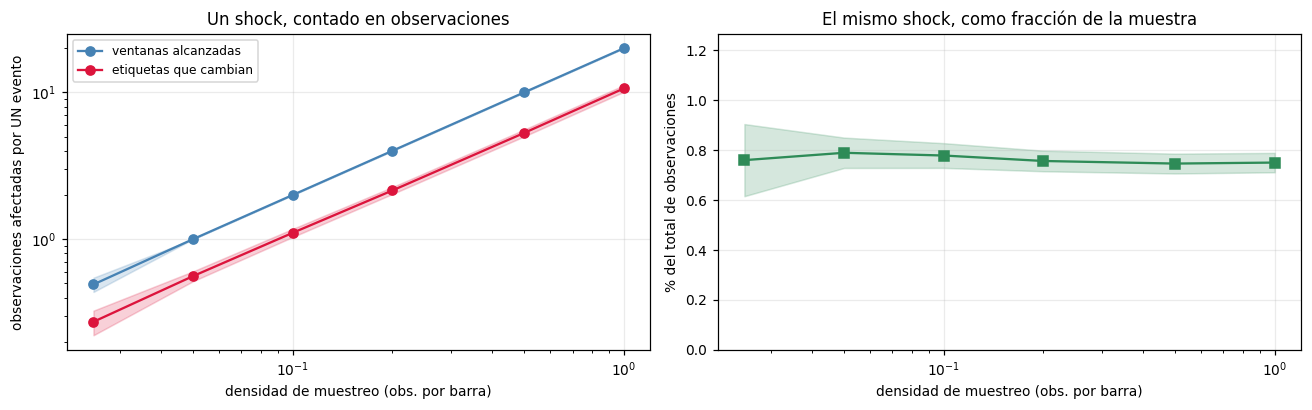

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
dens_obs = [1 / s for s in DENS]
for col, name, col_c in [("reached", "ventanas alcanzadas", "steelblue"),
                         ("changed", "etiquetas que cambian", "crimson")]:
    m = [mean_ci(prop[f"{col}|{s}"])["mean"] for s in DENS]
    lo = [mean_ci(prop[f"{col}|{s}"])["lo"] for s in DENS]
    hi = [mean_ci(prop[f"{col}|{s}"])["hi"] for s in DENS]
    a1.plot(dens_obs, m, "o-", color=col_c, label=name)
    a1.fill_between(dens_obs, lo, hi, alpha=0.2, color=col_c)
a1.set(xscale="log", yscale="log", xlabel="densidad de muestreo (obs. por barra)",
       ylabel="observaciones afectadas por UN evento",
       title="Un shock, contado en observaciones"); a1.legend(fontsize=8)

m = [mean_ci(prop[f"changed_frac|{s}"])["mean"] * 100 for s in DENS]
lo = [mean_ci(prop[f"changed_frac|{s}"])["lo"] * 100 for s in DENS]
hi = [mean_ci(prop[f"changed_frac|{s}"])["hi"] * 100 for s in DENS]
a2.plot(dens_obs, m, "s-", color="seagreen")
a2.fill_between(dens_obs, lo, hi, alpha=0.2, color="seagreen")
a2.set(xscale="log", xlabel="densidad de muestreo (obs. por barra)",
       ylabel="% del total de observaciones", ylim=(0, max(hi) * 1.4),
       title="El mismo shock, como fracción de la muestra")
plt.tight_layout(); plt.savefig(PLOTS / "03_propagation.png", bbox_inches="tight"); plt.show()

### Las dos curvas dicen cosas opuestas, y las dos son ciertas

La **fracción** contaminada es plana: da igual cómo muestree, un evento toca siempre el mismo
porcentaje de la muestra. Es una propiedad del horizonte y de la longitud de la serie, no del
muestreo. Quien reporte "solo el 0.8% de mis observaciones están contaminadas" está diciendo algo
verdadero e irrelevante.

El **recuento** crece linealmente con la densidad. Y ese es el número que importa para el
notebook 04, porque la pregunta de la fuga en validación cruzada no es "qué fracción de la muestra
está contaminada" sino **"cuántas filas de entrenamiento comparten información con esta fila de
test"**. Con una observación por barra, cada fila de test tiene ~20 vecinas que vieron sus mismos
retornos; con ventanas disjuntas, ninguna.

## 5. Tres esquemas de muestreo

* **una obs. por barra** — el máximo de filas posible.
* **CUSUM** (AFML Ch. 2) con varios umbrales: muestrea solo cuando el precio acumula un movimiento
  de `k` sigmas desde el último evento. Es muestreo *dirigido por la información*, no por el reloj.
* **ventanas disjuntas** — una observación cada `N` barras, sin solape por construcción.

Para cada uno: número de observaciones, unicidad media y tamaño efectivo. La pregunta es si el
CUSUM compra algo que no sea simplemente muestrear menos.

In [7]:
def schemes(sd):
    out = {"1 obs./barra": sd.all_events, "1 cada 5": sd.all_events[::5],
           "1 cada 10": sd.all_events[::10],
           f"disjuntas ({N_HOLD})": sd.all_events[::N_HOLD]}
    win = sd.bars.close.loc[sd.all_events[0]:sd.all_events[-1]]
    for k in (0.5, 1.0, 2.0, 3.0):
        out[f"CUSUM {k}s"] = cusum_events(win, sd.sigma1 * k)
    return out

def scheme_row(seed):
    sd = build(seed)
    row = {}
    for name, ev in schemes(sd).items():
        Le = label(sd, ev)
        if len(Le) < 5:
            continue
        cco = num_concurrent_events(sd.bars.index, Le)
        uu = average_uniqueness(sd.bars.index, Le, cco)
        dur = (Le.i1 - Le.i0).mean()
        row[f"{name}|n"] = len(Le)
        row[f"{name}|u"] = uu.mean()
        row[f"{name}|ess"] = effective_sample_size(uu)
        row[f"{name}|dur"] = dur
        row[f"{name}|T_over_dur"] = (len(sd.all_events)) / dur
    return row

sch = over_seeds(scheme_row)
names = list(schemes(build(0)).keys())
tab = pd.DataFrame({n: {k: mean_ci(sch[f"{n}|{k}"])["mean"] for k in ("n", "u", "ess", "dur")}
                    for n in names if f"{n}|n" in sch.columns}).T
tab.columns = ["nº obs.", "unicidad media", "tamaño efectivo (n·ū)", "duración media"]
tab["obs. por unidad efectiva"] = tab["nº obs."] / tab["tamaño efectivo (n·ū)"]
display(tab.round(3))
print(f"cota estructural  T / duración media ~ "
      f"{mean_ci(sch['1 obs./barra|T_over_dur'])['mean']:.1f}   "
      f"(T = {len(build(0).all_events)} barras)")

,nº obs.,unicidad media,tamaño efectivo (n·ū),duración media,obs. por unidad efectiva
1 obs./barra,"1,419.0000",0.0730,104.0420,14.3080,13.6390
1 cada 5,284.0000,0.3560,101.0500,14.2870,2.8100
1 cada 10,142.0000,0.6320,89.7010,14.3110,1.5830
disjuntas (20),71.0000,0.9710,68.9380,14.2510,1.0300
CUSUM 0.5s,852.9670,0.1210,103.1800,13.7250,8.2670
CUSUM 1.0s,539.4670,0.1900,102.1650,13.3560,5.2800
CUSUM 2.0s,267.2670,0.3720,99.2770,13.0960,2.6920
CUSUM 3.0s,157.4670,0.6050,95.1880,12.9680,1.6540


cota estructural  T / duración media ~ 99.3   (T = 1419 barras)


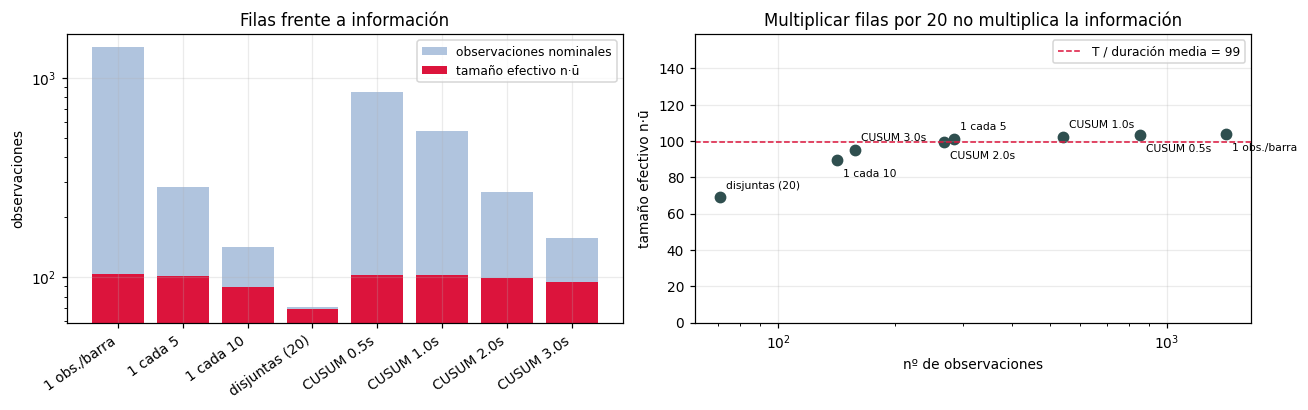

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
order = list(tab.index)
xs = np.arange(len(order))
a1.bar(xs, tab["nº obs."], color="lightsteelblue", label="observaciones nominales")
a1.bar(xs, tab["tamaño efectivo (n·ū)"], color="crimson", label="tamaño efectivo n·ū")
a1.set_xticks(xs); a1.set_xticklabels(order, rotation=35, ha="right")
a1.set(yscale="log", ylabel="observaciones", title="Filas frente a información")
a1.legend(fontsize=8)

a2.scatter(tab["nº obs."], tab["tamaño efectivo (n·ū)"], s=45, color="darkslategray")
for k, n in enumerate(order):
    a2.annotate(n, (tab.loc[n, "nº obs."], tab.loc[n, "tamaño efectivo (n·ū)"]),
                fontsize=7, xytext=(4, 6 if k % 2 else -11), textcoords="offset points")
bound = mean_ci(sch["1 obs./barra|T_over_dur"])["mean"]
a2.axhline(bound, color="crimson", ls="--", lw=1, label=f"T / duración media = {bound:.0f}")
a2.set(xscale="log", xlabel="nº de observaciones", ylabel="tamaño efectivo n·ū",
       ylim=(0, bound * 1.6), title="Multiplicar filas por 20 no multiplica la información")
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "03_sampling.png", bbox_inches="tight"); plt.show()

## 6. Predicción vs resultado

In [9]:
display(pd.DataFrame([
    {"magnitud": "unicidad media, 1 obs./barra", "predicho": "~0.05 (=1/N)",
     "obtenido": fmt_ci(mean_ci(sch["1 obs./barra|u"]), 4)},
    {"magnitud": "unicidad media, ventanas disjuntas", "predicho": "~1.0",
     "obtenido": fmt_ci(mean_ci(sch[f"disjuntas ({N_HOLD})|u"]), 4)},
    {"magnitud": "tamaño efectivo, 1 obs./barra", "predicho": "~75 (=T/N)",
     "obtenido": fmt_ci(mean_ci(sch["1 obs./barra|ess"]), 1)},
    {"magnitud": "tamaño efectivo, 1 cada 10", "predicho": "~75",
     "obtenido": fmt_ci(mean_ci(sch["1 cada 10|ess"]), 1)},
    {"magnitud": "tamaño efectivo, CUSUM 2σ", "predicho": "~75",
     "obtenido": fmt_ci(mean_ci(sch["CUSUM 2.0s|ess"]), 1)},
    {"magnitud": "tamaño efectivo, disjuntas", "predicho": "~75",
     "obtenido": fmt_ci(mean_ci(sch[f"disjuntas ({N_HOLD})|ess"]), 1)},
    {"magnitud": "etiquetas contaminadas por 1 shock (1 obs./barra)", "predicho": "~N = 20",
     "obtenido": fmt_ci(mean_ci(prop["changed|1"]), 1)},
    {"magnitud": "fracción contaminada, densidad x20", "predicho": "constante",
     "obtenido": f"{mean_ci(prop['changed_frac|1'])['mean']*100:.3f}% -> "
                 f"{mean_ci(prop['changed_frac|20'])['mean']*100:.3f}%"},
]).set_index("magnitud"))

,predicho,obtenido
magnitud,,
"unicidad media, 1 obs./barra",~0.05 (=1/N),"0.0733 [0.0725, 0.0742]"
"unicidad media, ventanas disjuntas",~1.0,"0.9710 [0.9693, 0.9726]"
"tamaño efectivo, 1 obs./barra",~75 (=T/N),"104.0 [102.8, 105.3]"
"tamaño efectivo, 1 cada 10",~75,"89.7 [88.8, 90.6]"
"tamaño efectivo, CUSUM 2σ",~75,"99.3 [98.2, 100.4]"
"tamaño efectivo, disjuntas",~75,"68.9 [68.8, 69.1]"
etiquetas contaminadas por 1 shock (1 obs./barra),~N = 20,"10.6 [10.1, 11.2]"
"fracción contaminada, densidad x20",constante,0.750% -> 0.789%


### Veredicto

**1. La predicción cualitativa se confirma; la constante que elegí era la equivocada.** Predije
tamaño efectivo `~T/N ~ 75` en todos los esquemas. Sale **~100** en todos los densos
(1 obs./barra 104.0 [102.8, 105.3], 1 cada 5 101.1, CUSUM 2σ 99.3, CUSUM 3σ 95.2). La constante
correcta no es `T/N` sino **`T / duración media de la apuesta`** = 99.3: las barreras se tocan
antes de vencer (14.2 barras de 20), así que el horizonte efectivo es más corto que el nominal.
Lo mismo pasa con la unicidad: 0.0733 [0.0725, 0.0742], que no es `1/N = 0.050` sino
`1/14.2 = 0.070`. Toda la aritmética de solape hay que hacerla con la duración **realizada**, no
con la barrera vertical.

**2. Multiplicar las filas por 20 no multiplica la información.** Pasar de ventanas disjuntas
(71 obs.) a una por barra (1419 obs.) es 20 veces más filas para un tamaño efectivo de 104 frente
a 69. Y cada esquema denso paga distinto por lo mismo: 13.6 observaciones nominales por unidad
efectiva de información con 1 obs./barra, 2.7 con CUSUM 2σ, 1.03 con ventanas disjuntas. El CUSUM
a 2σ da **el 95% de la información con el 19% de las filas**.

**3. Y sin embargo el muestreo "seguro" es el que peor sale parado.** Las ventanas disjuntas dan
68.9 [68.8, 69.1] frente a los ~100 disponibles: dejan sin usar el hueco entre el toque de barrera
y la siguiente muestra. Es decir, **eliminar el solape por completo tira un tercio de la
información**. La lectura no es "muestrea disjunto", es que hay un óptimo intermedio y que la
densidad es un parámetro a elegir, no un valor por defecto.

**4. Un solo evento contamina 10.6 [10.1, 11.2] etiquetas** con una observación por barra: de las
20 ventanas que lo contienen estructuralmente, poco más de la mitad cambian de valor. Ese recuento
escala con la densidad (10.6 → 5.3 → 2.1 → 1.1 → 0.6) mientras la **fracción se mantiene plana en
0.75-0.79%**. Las dos curvas son ciertas y dicen cosas contrarias; la que importa para la fuga en
validación cruzada es el recuento, porque la pregunta es cuántas filas de entrenamiento vieron los
mismos retornos que una fila de test dada.

**5. El tamaño efectivo de Kish es la herramienta equivocada aquí, y es una trampa fácil.** Con
pesos por unicidad dice **1101**; el solape dice **104**. Kish solo penaliza la dispersión de los
pesos y **supone independencia**, que es exactamente lo que aquí no se cumple. Ponderar por
unicidad no convierte la muestra en 1101 puntos independientes.

**Predicción para el notebook 04.** Si el tamaño efectivo es el mismo (~100) ponderando por
unicidad sobre 1419 filas que muestreando 267 con CUSUM 2σ, entonces las dos defensas deberían
rendir **parecido**, y ninguna de las dos debería arreglar por sí sola la fuga del k-fold
aleatorio: ambas corrigen *cuánto pesa* cada observación, no *dónde cae el corte* entre
entrenamiento y test. Queda escrito para contrastarlo.

**Lo que no quedó demostrado.**
* Que la unicidad media sea la ponderación *correcta*. Este notebook mide solape; que ponderar por
  él mejore un estimador es una afirmación distinta, y necesita un modelo. Es el notebook 04.
* Que los pesos por atribución de retorno aporten sobre los de unicidad. Correlacionan alto y aquí
  solo comparo sus distribuciones; su efecto sobre el rendimiento no está medido.
* No implementé el **bootstrap secuencial** (AFML 4.5), que es la otra defensa del capítulo. Los
  experimentos del 04 usan pesos y particiones, no remuestreo, así que el resultado de allí no
  dice nada sobre él.
* Todo esto es con `N=20` y una duración realizada de 14.2 barras. Las constantes cambian con el
  horizonte; las relaciones (`ū ~ 1/duración`, `ESS ~ T/duración`) no deberían, pero no lo he
  barrido.